# Biblioteki


In [328]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score, recall_score
from sklearn.ensemble import RandomForestClassifier

# Ładowanie danych

In [329]:
df_train = pd.read_csv('szpital.csv')
df_test = pd.read_csv('szpital_test.csv')

# Praca na danych


In [330]:
df_train

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,40.2,13.9,4.76,12.1,206,29.2,34.6,84.5,52,M,out
1,36.5,12.6,4.32,5.1,152,29.2,34.5,84.5,46,F,out
2,36.7,12.2,3.64,9.0,152,33.5,33.2,100.8,87,F,in
3,33.7,11.8,3.74,9.9,251,31.6,35.0,90.1,25,F,in
4,40.9,12.9,4.99,5.3,132,25.9,31.5,82.0,17,F,in
...,...,...,...,...,...,...,...,...,...,...,...
3907,36.5,12.7,3.82,10.2,241,33.2,34.8,95.5,59,F,in
3908,46.6,15.4,5.37,4.5,170,28.7,33.0,86.8,20,M,out
3909,42.0,13.7,4.67,8.7,143,29.3,32.6,89.9,55,M,out
3910,38.4,13.0,4.41,17.4,302,29.5,33.9,87.1,57,M,in


In [331]:
df_test.head()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX
0,42.3,13.8,5.00,7.3,289,27.6,32.6,84.6,22,M
1,42.8,13.2,4.89,7.4,326,27.0,30.8,87.5,82,F
2,46.4,16.4,5.24,15.6,241,31.3,35.3,88.5,15,M
3,37.3,12.8,4.40,4.2,106,29.1,34.3,84.8,25,F
4,51.6,18.2,6.26,13.3,262,29.1,35.3,82.4,38,M


In [332]:
plec_mapping = {'M': 0, 'F': 1}
source_mapping = {'in': 1, 'out': 0}

In [333]:
df_train['SEX'] = df_train['SEX'].map(plec_mapping).astype('float')
df_train['SOURCE'] = df_train['SOURCE'].map(source_mapping).astype('float')


df_test['SEX'] = df_test['SEX'].map(plec_mapping)


In [334]:
df_train.shape

(3912, 11)

In [335]:
df_train.describe()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
count,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.000000,3912.0000,3912.000000,3912.000000,3912.000000,3912.000000
mean,38.195015,12.739980,4.539926,8.740389,258.221881,28.238574,33.3432,84.626687,46.482618,0.483896,0.402863
std,5.983047,2.077783,0.784036,5.141133,114.613949,2.662162,1.2275,6.842860,21.691798,0.499804,0.490536
min,13.700000,3.800000,1.480000,1.100000,8.000000,14.900000,26.0000,54.000000,1.000000,0.000000,0.000000
25%,34.400000,11.400000,4.047500,5.600000,189.000000,27.200000,32.7000,81.600000,29.000000,0.000000,0.000000
50%,38.700000,12.900000,4.570000,7.600000,256.000000,28.700000,33.4000,85.400000,47.000000,0.000000,0.000000
75%,42.500000,14.200000,5.050000,10.400000,321.000000,29.800000,34.1000,88.725000,64.000000,1.000000,1.000000
max,69.000000,18.900000,7.860000,76.600000,1183.000000,40.800000,39.0000,115.600000,98.000000,1.000000,1.000000


In [336]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3912 entries, 0 to 3911
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HAEMATOCRIT   3912 non-null   float64
 1   HAEMOGLOBINS  3912 non-null   float64
 2   ERYTHROCYTE   3912 non-null   float64
 3   LEUCOCYTE     3912 non-null   float64
 4   THROMBOCYTE   3912 non-null   int64  
 5   MCH           3912 non-null   float64
 6   MCHC          3912 non-null   float64
 7   MCV           3912 non-null   float64
 8   AGE           3912 non-null   int64  
 9   SEX           3912 non-null   float64
 10  SOURCE        3912 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 336.3 KB


In [337]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HAEMATOCRIT   500 non-null    float64
 1   HAEMOGLOBINS  500 non-null    float64
 2   ERYTHROCYTE   500 non-null    float64
 3   LEUCOCYTE     500 non-null    float64
 4   THROMBOCYTE   500 non-null    int64  
 5   MCH           500 non-null    float64
 6   MCHC          500 non-null    float64
 7   MCV           500 non-null    float64
 8   AGE           500 non-null    int64  
 9   SEX           500 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 39.2 KB


# Klasyfikacja

In [338]:
X_train = df_train.drop(columns='SOURCE')
y_train = df_train['SOURCE']


/Users/mikolajkoszewski/Library/Mobile Documents/com~apple~CloudDocs/Studia/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


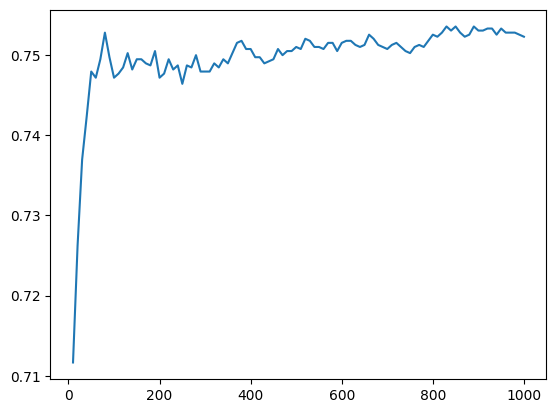

In [339]:
rate = []
min_estimators = 10
max_estimators = 1000


rf = RandomForestClassifier(warm_start=True, oob_score=True,
                               max_features="sqrt", n_jobs=-1, bootstrap=True, class_weight={0: 1, 1: 10})

for i in range(min_estimators,max_estimators+1, 10):
    rf.set_params(n_estimators=i)
    rf.fit(X_train,y_train)

    rate.append(rf.oob_score_)

x_axis = range(min_estimators,max_estimators+1, 10)

plt.plot(x_axis, rate)
plt.show()


In [340]:
rf = RandomForestClassifier(n_estimators = 250, n_jobs=-1)

dobieranie parametrów

In [341]:
wagi = [{0: 1, 1: w} for w in np.arange(1, 20)] + ['balanced', 'balanced_subsample']

param_grid = {
    'max_depth': list(np.arange(2, 9)) + [None], 
    'min_samples_leaf': range(1, 31), 
    'max_features': list(np.arange(1, 9)) + [None], 
    'max_samples': list(np.arange(0.1, 1.0, 0.1)) + [None], 
    'class_weight': wagi
}

rf_rscv = RandomizedSearchCV(rf, param_grid, n_iter=100, cv=5, scoring='f1', n_jobs=-1)
rf_rscv.fit(X_train, y_train)

,estimator,"RandomForestC...50, n_jobs=-1)"
,param_distributions,"{'class_weight': [{0: 1, 1: np.int64(1)}, {0: 1, 1: np.int64(2)}, ...], 'max_depth': [np.int64(2), np.int64(3), ...], 'max_features': [np.int64(1), np.int64(2), ...], 'max_samples': [np.float64(0.1), np.float64(0.2), ...], ...}"
,n_iter,100
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [342]:
rf_rscv.best_params_

{'min_samples_leaf': 4,
 'max_samples': np.float64(0.7000000000000001),
 'max_features': np.int64(1),
 'max_depth': None,
 'class_weight': {0: 1, 1: np.int64(2)}}

In [343]:
y_pred_best = rf_rscv.predict(df_test)

Wyniki koncowe


In [344]:
wynik_df = pd.DataFrame({'SOURCE': y_pred_best})
reversed_mapping = {1: 'in', 0: 'out'}
wynik_df['SOURCE'] = wynik_df['SOURCE'].map(reversed_mapping)

In [345]:
wynik_df.to_csv('s.csv', index=False)